# Encoder Inference: Image → fMRI

This notebook walks through the same pipeline as `inference/encoder_inference.py`.

**What it does**
1. Loads the Universal Brain Encoder checkpoint
2. Predicts fMRI responses for the shared NSD test images (`type_sample == 2`)
3. Saves per-subject predictions
4. Compares predictions to measured fMRI (`multi_sub_fmri`) with per-voxel Pearson correlation

**Prerequisites**
- Processed NSD data under `data/nsd_data/` (see the main README)
- Encoder checkpoint under `results/saved_models/` (train or download)

Run from `models/` or the repo root; the next cell moves to the repo root if needed.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from pathlib import Path

if Path.cwd().name == "inference":
    os.chdir("..")
print("Working directory:", Path.cwd())


Working directory: /net/mraid20/ifs/wisdom/userdata/romanb/universal-brain-encoder_debug


## 1. Setup

Import libraries and define paths. Subject IDs are **1-based** (`1` = subj01, …, `8` = subj08).
Default subjects `[1, 2, 5, 8]` are the four NSD subjects with the most sessions.

In [2]:
import numpy as np
import torch
from scipy.stats import pearsonr
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = "data/nsd_data/"
MODEL_DIR = "results/saved_models/"
OUTPUT_DIR = "results/encoder_predictions/test/"

SUBJECTS = [1, 2, 5, 7]  # 1-based subject numbers
MODEL_PATH = MODEL_DIR + f"encoder_ch128.pth"

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406]).reshape([1, 1, 3]).astype(float)
IMAGENET_STD = np.array([0.229, 0.224, 0.225]).reshape([1, 1, 3]).astype(float)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Model: {MODEL_PATH}")
print(f"Subjects: {SUBJECTS}")

Using device: cuda
Model: results/saved_models/encoder_ch128.pth
Subjects: [1, 2, 5, 7]


## 2. Image preprocessing

Images are scaled to `[0, 1]`, normalized with ImageNet mean/std, and converted to CHW tensors for the DINOv2-based encoder.

In [3]:
def preprocess_image(img):
    # Normalize a single uint8 HWC image for the encoder.
    img = (img / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    img = img.transpose([2, 0, 1])
    return torch.from_numpy(img.astype(float)).float()

## 3. Load data

- `fmri_v2.npz` holds voxel counts, measured multi-subject fMRI, and `type_sample`
- `type_sample == 2` marks the **shared test images** seen by all subjects (aligned with `multi_sub_fmri`)
- Voxels for each subject are concatenated along the voxel axis of `multi_sub_fmri`

In [4]:
fmri_data = np.load(DATA_DIR + "fmri_v2.npz")
num_voxels_subjects = fmri_data["num_voxels_subjects"].astype(int)
type_sample = fmri_data["type_sample"]

print("Voxels per subject:", num_voxels_subjects)
print("Total voxels:", int(num_voxels_subjects.sum()))

images = np.load(DATA_DIR + "nsd_images_224.npy")
images = images[type_sample == 2]
print(f"Test / shared images: {images.shape}")  # [N, 224, 224, 3]

y_true = fmri_data["multi_sub_fmri"].astype(np.float32)
print(f"Measured multi-subject fMRI: {y_true.shape}")  # [N, sum(voxels)]

Voxels per subject: [39548 39548 39548 39548 39548 39198 39548 39511]
Total voxels: 315997
Test / shared images: (1000, 224, 224, 3)
Measured multi-subject fMRI: (1000, 315997)


## 4. Load the encoder

The checkpoint is a full PyTorch model object (including the frozen DINOv2 backbone and trained readout).

In [5]:
print(f"Loading encoder from {MODEL_PATH}...")
torch.hub.set_dir("data/external_models/torch_hub/")
torch.hub.load("facebookresearch/dinov2", "dinov2_vits14_reg")  # needed so encoder model can load
encoder_model = torch.load(MODEL_PATH, map_location=device).eval().to(device)
print("Model loaded.")


Loading encoder from results/saved_models/encoder_ch128.pth...


Using cache found in data/external_models/torch_hub/facebookresearch_dinov2_main
/net/mraid20/ifs/wisdom/userdata/romanb/universal-brain-encoder_debug/data/external_models/torch_hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/net/mraid20/ifs/wisdom/userdata/romanb/universal-brain-encoder_debug/data/external_models/torch_hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/net/mraid20/ifs/wisdom/userdata/romanb/universal-brain-encoder_debug/data/external_models/torch_hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/home/romanb/data/miniconda3/envs/encoder_debug/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be rem

Model loaded.


Model loaded.


## 5. Predict fMRI per subject

For each subject we:
1. Select that subject's voxel index range in the concatenated voxel layout
2. Pass each image through the encoder with those voxel indices
3. Store predictions in a dictionary keyed by `subject_{N}`

In [6]:
def predict_fmri(encoder_model, images, num_voxels_subjects, subjects, device):
    num_images = images.shape[0]
    end = np.cumsum(num_voxels_subjects)
    start = end - num_voxels_subjects

    fmri = {}
    for sub in subjects:
        idx = sub - 1  # convert 1-based subject id -> array index
        n_vox = int(end[idx] - start[idx])
        vox_ind = torch.arange(start[idx], end[idx], device=device).unsqueeze(0)
        sub_fmri = np.zeros([num_images, n_vox], dtype=np.float32)

        print(f"Predicting fMRI for subject {sub} ({num_images} images, {n_vox} voxels)...")
        for i in range(num_images):
            if i % 100 == 0:
                print(f"  Processing image {i}/{num_images}")
            image_tensor = preprocess_image(images[i]).unsqueeze(0)
            with torch.no_grad():
                pred = encoder_model(image_tensor.to(device), vox_ind)
            sub_fmri[i] = pred.detach().cpu().numpy()

        fmri[f"subject_{sub}"] = sub_fmri
    return fmri

fmri_pred = predict_fmri(encoder_model, images, num_voxels_subjects, SUBJECTS, device)
for k, v in fmri_pred.items():
    print(f"  {k}: {v.shape}")

Predicting fMRI for subject 1 (1000 images, 39548 voxels)...
  Processing image 0/1000
  Processing image 100/1000
  Processing image 200/1000
  Processing image 300/1000
  Processing image 400/1000
  Processing image 500/1000
  Processing image 600/1000
  Processing image 700/1000
  Processing image 800/1000
  Processing image 900/1000
Predicting fMRI for subject 2 (1000 images, 39548 voxels)...
  Processing image 0/1000
  Processing image 100/1000
  Processing image 200/1000
  Processing image 300/1000
  Processing image 400/1000
  Processing image 500/1000
  Processing image 600/1000
  Processing image 700/1000
  Processing image 800/1000
  Processing image 900/1000
Predicting fMRI for subject 5 (1000 images, 39548 voxels)...
  Processing image 0/1000
  Processing image 100/1000
  Processing image 200/1000
  Processing image 300/1000
  Processing image 400/1000
  Processing image 500/1000
  Processing image 600/1000
  Processing image 700/1000
  Processing image 800/1000
  Processin

## 6. Save predictions

Predictions are stored as float16 in a single `.npz` file, one array per subject.

In [7]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

pred_path = output_dir / "pred_fmri.npz"
np.savez(pred_path, **{k: v.astype(np.float16) for k, v in fmri_pred.items()})
print(f"Saved predictions -> {pred_path}")

Saved predictions -> results/encoder_predictions/test/pred_fmri.npz


## 7. Evaluate: per-voxel correlation

For each subject, correlate predicted vs measured activity across test images for every voxel.
We report the **median** correlation (more robust than the mean for noisy voxels).

In [8]:
def compute_voxel_correlations(y_true, y_pred):
    num_voxels = y_true.shape[1]
    corr = np.zeros(num_voxels, dtype=np.float32)
    for i in range(num_voxels):
        corr[i] = pearsonr(y_true[:, i], y_pred[:, i])[0]
    return np.nan_to_num(corr)

end = np.cumsum(num_voxels_subjects)
start = end - num_voxels_subjects

corr_dict = {}
print("Per-subject median voxel correlation:")
for sub in SUBJECTS:
    idx = sub - 1
    key = f"subject_{sub}"
    sub_corr = compute_voxel_correlations(
        y_true[:, start[idx]:end[idx]],
        fmri_pred[key],
    )
    corr_dict[key] = sub_corr
    print(f"  subject {sub}: {np.median(sub_corr):.4f}  (n_voxels={len(sub_corr)})")

all_corr = np.concatenate(list(corr_dict.values()))
print(f"Overall median: {np.median(all_corr):.4f}")

corr_path = output_dir / "voxel_corr.npz"
np.savez(corr_path, **corr_dict)
print(f"Saved correlations -> {corr_path}")

Per-subject median voxel correlation:
  subject 1: 0.5427  (n_voxels=39548)
  subject 2: 0.5654  (n_voxels=39548)
  subject 5: 0.5853  (n_voxels=39548)
  subject 7: 0.4299  (n_voxels=39548)
Overall median: 0.5289
Saved correlations -> results/encoder_predictions/test/voxel_corr.npz


## 8. Visualize correlation distributions

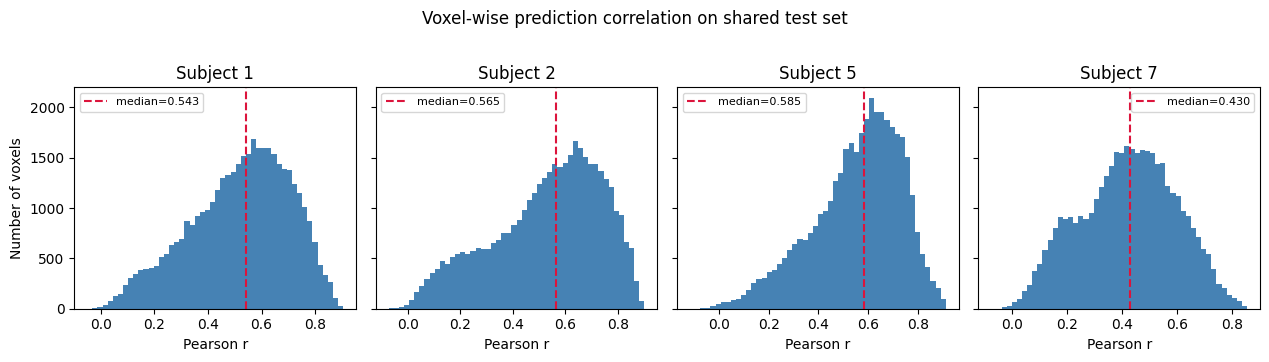

In [9]:
fig, axes = plt.subplots(1, len(SUBJECTS), figsize=(3.2 * len(SUBJECTS), 3.5), sharey=True)
if len(SUBJECTS) == 1:
    axes = [axes]

for ax, sub in zip(axes, SUBJECTS):
    c = corr_dict[f"subject_{sub}"]
    ax.hist(c, bins=50, color="steelblue", edgecolor="none")
    ax.axvline(np.median(c), color="crimson", linestyle="--", label=f"median={np.median(c):.3f}")
    ax.set_title(f"Subject {sub}")
    ax.set_xlabel("Pearson r")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Number of voxels")
fig.suptitle("Voxel-wise prediction correlation on shared test set", y=1.02)
plt.tight_layout()
plt.show()

## Notes

- **CLI equivalent:** `python inference/encoder_inference.py`
- **Custom images / ROI prediction:** see `inference/predict_fmri_for_images.py` and the main README
- **Transfer models:** use `python inference/encoder_inference.py --transfer --subject N` after training a transfer checkpoint
- Full test-set prediction can take a while on GPU; for a quick smoke test, slice `images` / `y_true` to fewer images before calling `predict_fmri`